<a href="https://colab.research.google.com/github/jirvingphd/ai-aoe-workshop-backup/blob/main/notebooks_fixed_vers/(AICOE_Workshop_01)_LangChain_Tools_Agents_Chains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Workshop 1: LangChain Tools, Agents & Chains

## Introduction


**LangChain** is an **open-source framework** designed to simplify the creation of applications using **large language models (LLMs)**. It provides a standard interface for chains, lots of integrations with other tools, and end-to-end chains for common applications. It allows AI developers to develop applications based on the combined Large Language Models (LLMs) such as GPT-4 with external sources of computation and data. This framework comes with a package for both Python and JavaScript.

LangChain's design not only facilitates the integration of LLMs with external data sources but also orchestrates complex workflows involving data retrieval, processing, and response generation, thus enabling the creation of highly interactive and intelligent applications. It operates through a systematic pipeline designed to enhance the functionality of large language models (LLMs). Initially, a user poses a question, which LangChain converts into a vector representation using an embedding model. This vector is then utilized to perform a similarity search within a vector database, allowing the system to retrieve relevant information based on semantic similarity. The fetched data is subsequently fed back into the language model, which processes this contextually enriched input. Leveraging this information, the language model generates a more accurate and contextually relevant response or takes a specified action.

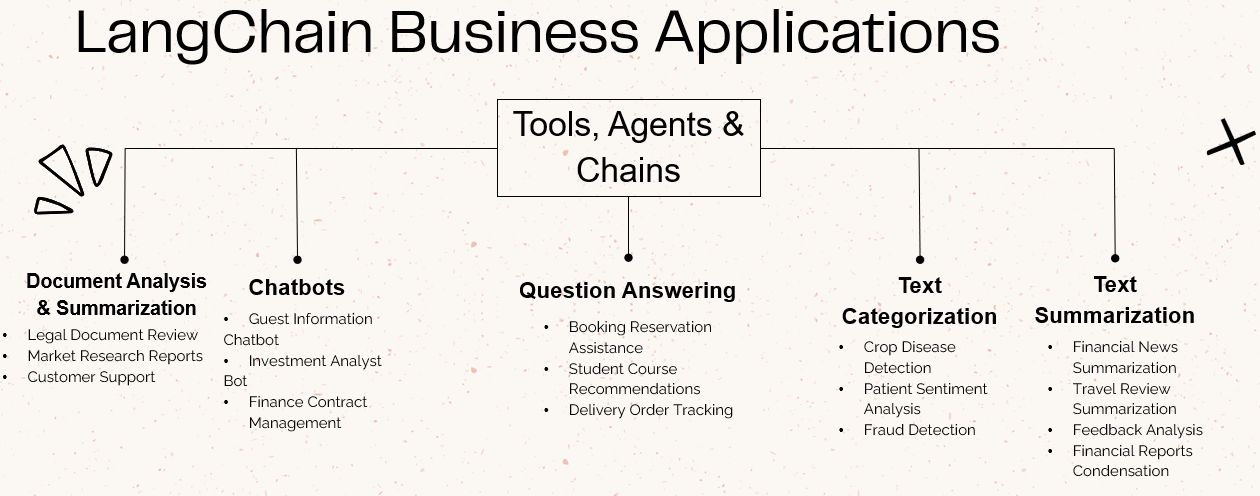

There are three main components within LangChain:
- Tools
- Agents
- Chains

## Tools

#### **Overview**
Tools in LangChain are modular components that allow language models to interact with external systems, perform tasks, and process data. These tools extend the capabilities of the model beyond simple text generation by enabling it to execute specific functions, such as interacting with APIs, querying databases, running Python code, or even controlling other software.

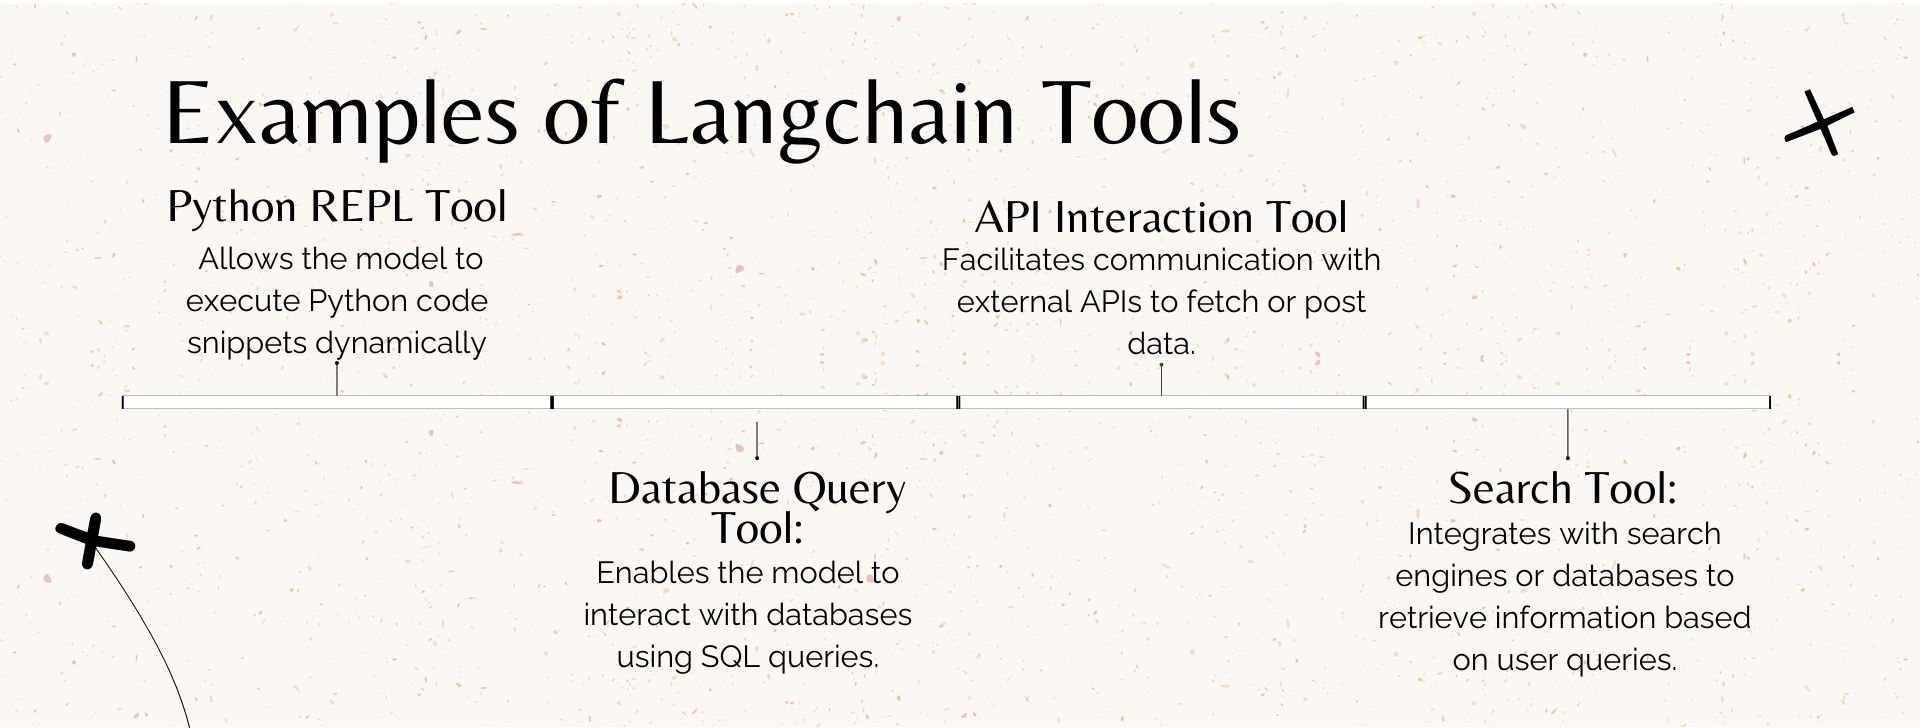

Tools can be pre built or custom.

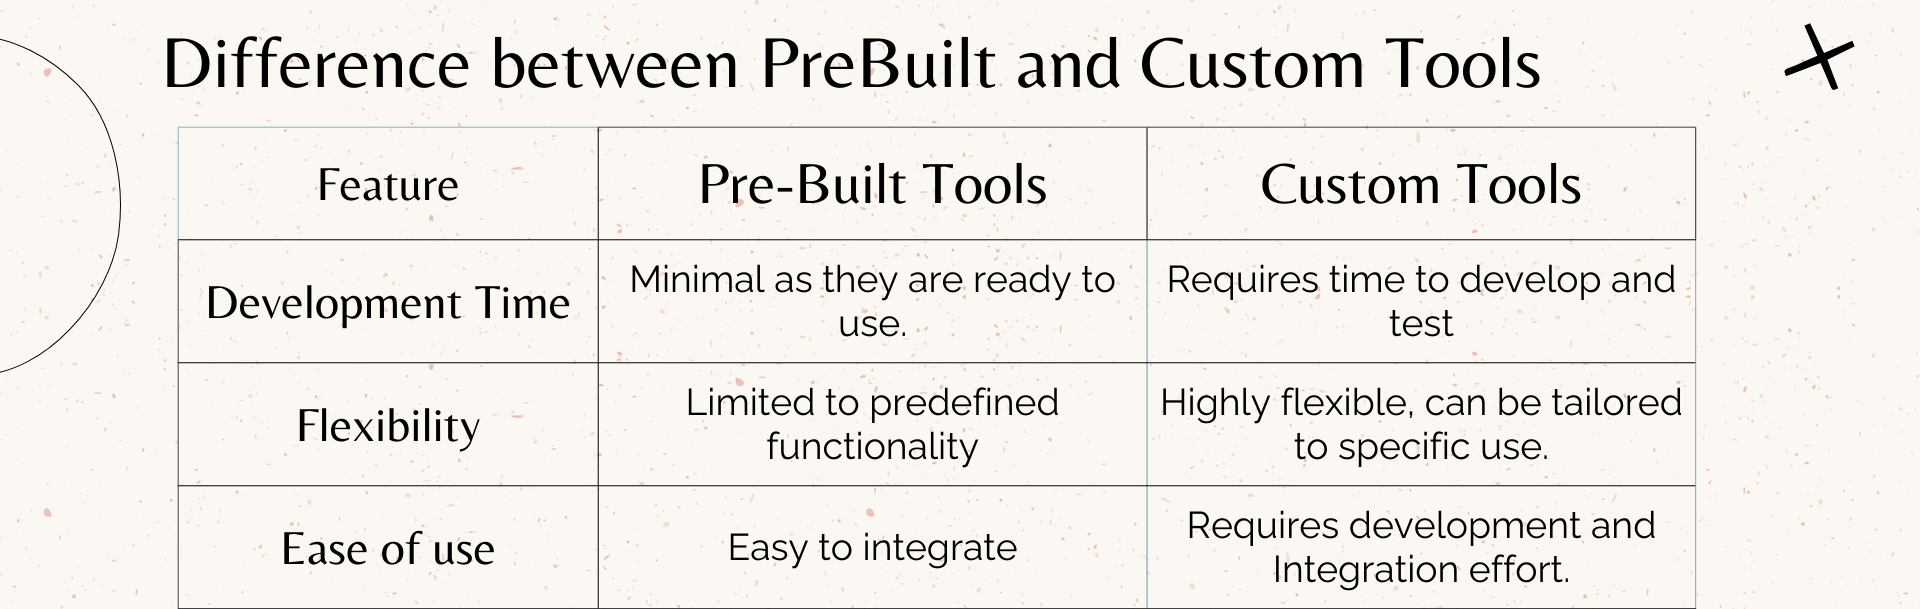

**Setting Up The Environment**:

-   Install required libraries

In [ ]:
# Install relevant packages
# 08/08/25 - exact versions added
!pip install langchain-community==0.3.27
!pip install tavily-python==0.7.10
!pip install langchain==0.3.27
!pip install wikipedia==1.4.0
!pip install langchain-experimental==0.3.4
!pip install openai==1.98.0
!pip install langchain-openai==0.3.28

-   Import and instantiate your API key.

In [ ]:
# Importing all the necessary libraries needed for this workbook

# LangChain Library (General Import)
import langchain
import openai

# LangChain Core Components
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.tools import BaseTool, tool

# LangChain Community Tools
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from tavily import TavilyClient
from pydantic import Field
from langchain import LLMChain

# LangChain Experimental Tools
from langchain_experimental.tools import PythonREPLTool

# LangChain OpenAI Integrations
from langchain_openai import ChatOpenAI, OpenAI

# LangChain Agents
from langchain.agents import AgentExecutor, create_tool_calling_agent, initialize_agent

# LangChain Chains
from langchain.chains import SimpleSequentialChain
from langchain.chains.router import MultiPromptChain
from langchain.chains.router.llm_router import LLMRouterChain, RouterOutputParser

# LangChain Prompts
from langchain.prompts import PromptTemplate

# Other Libraries
from getpass import getpass
import os
import datetime
import re
from collections import Counter
from typing import Optional, Any, Union
from math import sqrt, cos, sin
import warnings

# Suppress specific warning
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# #Define an OpenAI API Key
OPENAI_API_KEY = getpass('Enter the OpenAI API key value: ')
print("Successfully assigned an OpenAI API Key!")

# ## UPDATE FROM WORKSHOP 4
# from google.colab import userdata
# ## API Key from Secrets sidebar
# OPENAI_API_KEY =  userdata.get('OPENAI_API_KEY')


os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

**Pre-Built Tools** : Outlined below are examples of some pre-built Langchain tools.


In [ ]:
# 1. The first one is Wikipedia Query Tool that allows you to fetch information directly from Wikipedia, making it useful for retrieving facts or explanations.

# Initialize the OpenAI model
llm = ChatOpenAI(
    openai_api_key=OPENAI_API_KEY,  # Replace with your actual OpenAI API key
    model_name='gpt-3.5-turbo',
    temperature=0
)

# Initialize the Wikipedia API wrapper
wikipedia_api_wrapper = WikipediaAPIWrapper()

# Initialize the Wikipedia tool with the API wrapper
wikipedia_tool = WikipediaQueryRun(api_wrapper=wikipedia_api_wrapper)

# Set up the agent with the Wikipedia tool
tools = [wikipedia_tool]

agent = initialize_agent(
    agent='zero-shot-react-description',
    tools=tools,
    llm=llm,
    verbose=True
)

# Test the Wikipedia Tool
response = agent("Tell me short history of the White House.")
print(response)




> Entering new AgentExecutor chain...
I should look up the history of the White House to provide a concise summary.
Action: wikipedia
Action Input: White House
Observation: Page: White House
Summary: The White House is the official residence and workplace of the president of the United States. Located at 1600 Pennsylvania Avenue NW in Washington, D.C., it has served as the residence of every U.S. president since John Adams in 1800 when the national capital was moved from Philadelphia. "The White House" is also used as a metonym to refer to the Executive Office of the President of the United States.
The residence was designed by Irish-born architect James Hoban in the Neoclassical style. Hoban modeled the building on Leinster House in Dublin, a building which today houses the Oireachtas, the Irish legislature. Constructed between 1792 and 1800, its exterior walls are Aquia Creek sandstone painted white. When Thomas Jefferson moved into the house in 1801, he and architect Benjamin Henr

In [ ]:
#2. This second tool is the Python REPL Tool in LangChain that allows the agent to execute Python code directly, enabling it to perform tasks such as calculations, data manipulations, and running custom scripts easily.

def setup_python_repl_agent(api_key):
    """
    Initializes the Python REPL Tool agent for calculations.
    """
    # Initialize the Python REPL Tool
    python_repl_tool = PythonREPLTool()

    # Initialize the OpenAI model
    llm = ChatOpenAI(
        openai_api_key=OPENAI_API_KEY,
        model_name='gpt-3.5-turbo',
        temperature=0
    )

    # Set up the agent with the Python REPL Tool
    tools = [python_repl_tool]

    agent = initialize_agent(
        agent='zero-shot-react-description',
        tools=tools,
        llm=llm,
        verbose=True
    )
    return agent

def test_python_repl_agent(agent):
    """
    Test the Python REPL agent with a sample arithmetic query.
    """
    response = agent("Calculate 25 multiplied by 4.")
    print(response)


python_repl_agent = setup_python_repl_agent(OPENAI_API_KEY)
test_python_repl_agent(python_repl_agent)




> Entering new AgentExecutor chain...


I can easily calculate this using Python.
Action: Python_REPL
Action Input: 25 * 4
Observation: 
Thought:The result is 100.
Final Answer: 100

> Finished chain.
{'input': 'Calculate 25 multiplied by 4.', 'output': '100'}


**Simple Custom Tools**: Outlined below are examples of simple custom Langchain tools.

In [ ]:
#3. These mathematical tools allows the agent to execute division, subtraction and exponentiation on an input user query, in any order.

@tool
def divide(first_int: int, second_int: int) -> float:
    """Divide the first integer by the second integer."""
    if second_int == 0:
        return "Error: Division by zero is not allowed."
    return first_int / second_int

# Correct subtract function
@tool
def subtract(first_int: int, second_int: int) -> int:
    """Subtract the second integer from the first integer."""
    return first_int - second_int

# Correct exponentiate function
@tool
def exponentiate(base: int, exponent: int) -> int:
    """Exponentiate the base to the exponent power."""
    return base ** exponent

tools = [divide, subtract, exponentiate]

**Complex Custom Tools** <br>
Provided below is a Trend Analysis Tool that integrates with the Tavily API to fetch and analyze search results for a given industry and date range. It performs text extraction, cleans and analyzes the data to identify top emerging trends, and generates a summary with actionable recommendations. This tool combines API integration, data processing, and dynamic insight generation, making it ideal for tracking market trends and providing strategic insights.

In [ ]:
#Tavily is a search API, specifically designed for AI agents and tailored for RAG purposes.
#Define a Tavily API Key
# TAVILY_API_KEY = getpass('Enter the Tavily Search Tool API key value: ')
# print("Successfully assigned a Tavily Search Tool API Key!")

TAVILY_API_KEY  = userdata.get("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
tool = TavilySearchResults(tavily_api_key=TAVILY_API_KEY)
client = TavilyClient(api_key=TAVILY_API_KEY)

In [ ]:
# Below is a complex custom Trend Analysis tool that implements text data cleaning methods to understand the frequency of searched words in a search tool.

class TrendAnalysisTool(BaseTool):

    ## Added 08/08/25 to avoid errors with current packages
    name: str = "Trend Analysis Tool" # Added type annotation
    description: str = ( # Added type annotation
        "This tool tracks emerging trends in a specified industry within a given date range. "
        "It analyzes search results to identify the most common terms and provides recommendations based on the findings."
    )
    ##

    #The Field function from the pydantic library is used to customize and add metadata to models
    # Define a field for the search tool
    search_tool: Any = Field(..., description="The search tool used to fetch data.")

    def _run(
        self,
        industry: str,
        start_date: Optional[datetime.datetime] = None,
        end_date: Optional[datetime.datetime] = None
    ) -> str:
        try:
            # Convert dates to the required format
            start_date_str = start_date.strftime('%Y-%m-%d')
            end_date_str = end_date.strftime('%Y-%m-%d')

            # Fetch search results within the specified date range
            query = f"{industry} after:{start_date_str} before:{end_date_str}"
            results = self.search_tool.invoke({"query": query})  # Use the search tool passed during initialization

            if not results:
                return "No results found for the given industry and date range."

            # Extract and combine relevant snippets from the results
            combined_text = " ".join([result.get('content', '') for result in results])

            # Advanced trend analysis: track the frequency of specific terms over time
            words = re.findall(r'\b[a-zA-Z]{3,}\b', combined_text.lower())
            common_words = Counter(words)

            # Exclude common stop words and irrelevant terms
            stop_words = set([
                "the", "and", "is", "in", "to", "of", "for", "on", "a", "with",
                "from", "by", "this", "that", "it", "as", "at", "are", "was",
                "we", "an", "be", "or", "but", "not", "have", "has", "had",
                "their", "which", "will", "can", "also", "more", "up", "out",
                "all", "one", "new", "has", "other", "you", "over", "such", "about"
            ])
            filtered_words = {word: count for word, count in common_words.items() if word not in stop_words}

            # Get the top 10 most common words or emerging trends
            top_trends = Counter(filtered_words).most_common(10)

           # Summarize the findings
            summary = f"Emerging Trends in {industry} ({start_date_str} to {end_date_str}):\n\n"
            for word, count in top_trends:
                summary += f"- {word}: mentioned {count} times\n"

            # Convert top_trends to a set of words for easy checking
            top_trend_words = {word for word, count in top_trends}



            # Provide recommendations or insights based on the trends
            summary += "\nRecommendations:\n"

            # Check for each specific term in the filtered words to generate relevant recommendations
            if "innovation" in top_trend_words:
                summary += "- Increased mentions of 'innovation' suggest a focus on new technologies. Consider exploring partnerships with startups.\n"
            if "regulation" in top_trend_words:
                summary += "- 'Regulation' is frequently mentioned. Stay updated on policy changes to avoid compliance risks.\n"
            if "solar" in top_trend_words:
                summary += "- 'Solar' is emerging as a key trend. Consider expanding investments in solar technology.\n"
            if "wind" in top_trend_words:
                summary += "- 'Wind energy' shows significant attention. Explore opportunities in wind energy projects.\n"
            if "data" in top_trend_words:
                summary += "- 'Data' and 'analysis' are frequently mentioned. Investing in data analytics and data-driven decision-making could be beneficial.\n"
            if "capacity" in top_trend_words:
                summary += "- The frequent mention of 'capacity' suggests a focus on increasing renewable energy capacity. Consider exploring investments in new infrastructure.\n"

            return summary.strip()

        except Exception as e:
            return f"Error tracking emerging trends: {e}"

    def _arun(self, industry: str, start_date: datetime.datetime, end_date: datetime.datetime):
        raise NotImplementedError("This tool does not support async.")

search_tool =  TavilySearchResults(max_results=2)

# Initialize the trend analysis tool with the search tool
trend_analysis_tool = TrendAnalysisTool(search_tool=search_tool)

# Set the example parameters
industry = "renewable energy"
start_date = datetime.datetime(2023, 1, 1)
end_date = datetime.datetime(2023, 12, 31)

# Invoke the tool directly
trends_summary = trend_analysis_tool._run(industry, start_date, end_date)
print(trends_summary)

Emerging Trends in renewable energy (2023-01-01 to 2023-12-31):

- capacity: mentioned 7 times
- wind: mentioned 6 times
- growth: mentioned 4 times
- energy: mentioned 4 times
- solar: mentioned 4 times
- generation: mentioned 4 times
- could: mentioned 3 times
- largest: mentioned 3 times
- another: mentioned 3 times
- renewable: mentioned 3 times

Recommendations:
- 'Solar' is emerging as a key trend. Consider expanding investments in solar technology.
- 'Wind energy' shows significant attention. Explore opportunities in wind energy projects.
- The frequent mention of 'capacity' suggests a focus on increasing renewable energy capacity. Consider exploring investments in new infrastructure.


In [ ]:
# Below is a Pythagoras tool that implements the pythagoras equation on natural language user queries.

desc = (
    "use this tool when you need to calculate the length of an hypotenuse "
    "given one or two sides of a triangle and/or an angle (in degrees). "
    "To use the tool you must provide at least two of the following parameters "
    "['adjacent_side', 'opposite_side', 'angle']."
)

class PythagorasTool(BaseTool):

    ## Added 08/08/25 to avoid errors with current packages
    name: str = "Hypotenuse calculator" # Added type annotation
    description: str = desc # Added type annotation
    ##

    def _run(
        self,
        adjacent_side: Optional[Union[int, float]] = None,
        opposite_side: Optional[Union[int, float]] = None,
        angle: Optional[Union[int, float]] = None
    ):
        # check for the values we have been given
        if adjacent_side and opposite_side:
            return sqrt(float(adjacent_side)**2 + float(opposite_side)**2)
        elif adjacent_side and angle:
            return adjacent_side / cos(float(angle))
        elif opposite_side and angle:
            return opposite_side / sin(float(angle))
        else:
            return "Could not calculate the hypotenuse of the triangle. Need two or more of `adjacent_side`, `opposite_side`, or `angle`."

    def _arun(self, query: str):
        raise NotImplementedError("This tool does not support async")

tool = PythagorasTool()

result = tool._run(adjacent_side=3, opposite_side=4)
print(result)

5.0


## Agents

#### **Overview** <br>
Agents use a language model to figure out which actions to take and in what order. Unlike fixed action sequences in chains, agents let the model decide on the fly. They enable LLMs to use tools like Google search, Python, and SQL queries. This makes agents different from traditional ChatGPT implementations and shows what langchain can do.

---

*In short, agents help LLMs choose actions and use tools as needed.*

---

Agents are vital for a number of reasons ▶
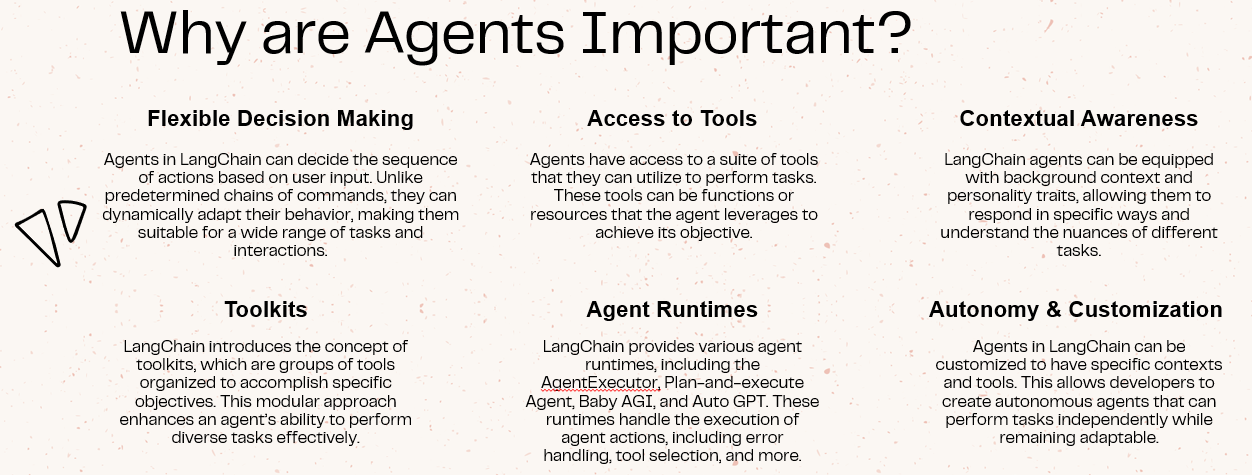

#### **Examples**
Here are a few examples of agents and what they can do ▶

*   **Search Agent**: Uses a language model to determine when to perform a Google search, then processes and incorporates the search results into its responses.
*   **Calculator Agent**: Decides when to perform complex mathematical calculations using Python and integrates the results into the conversation.
*   **SQL Query Agent**: Chooses when to run SQL queries on a database to fetch or manipulate data, then uses the results to inform responses or decisions.

<br>

Outlined below is an example of using an agent with a simple custom tool

In [ ]:
#A ChatOpenAI is a chat model that takes a list of messages as input and return a model-generated message as output.

#Define a ChatOpenAI object with a model and an OpenAI API key
llm = ChatOpenAI(model="gpt-4-turbo", #gpt-3.5-turbo
                 temperature=0, #used to control the randomness of the output
                 api_key=OPENAI_API_KEY
                )

In [ ]:
#Now, we define the prompt that will guide the agent or provide it with instructions on what it needs to do

#ChatPromptTemplate is the prompt that we pass along to an OpenAI Chat model
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful mathematician. Answer the following question.", # system message that sets the instructions for the agent
        ),
        ("placeholder", "{chat_history}"), #placeholder for dynamic content that will be inserted at runtime.
        ("human", "{input}"), #message from the user or human participant in the conversation.
        ("placeholder", "{agent_scratchpad}"), #placeholder for any additional notes or temporary information the agent might use during the conversation.
    ]
)

In [ ]:
#Define a set of custom mathematical tools to select from
tools = [divide, subtract, exponentiate]

#Bind an agent to an llm model, a set of tools and a prompt which will give it a role
agent = create_tool_calling_agent(llm, tools, prompt)

In [ ]:
#AgentExecutor is a class that executes the action of the agent on the specific tools. It repeats this process iteratively until the agent is satisfied with the model output response.
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

response = agent_executor.invoke({
"input": "Take 2 to the power of 5 and divide the result obtained by the result of subtracting 8 from 24, then square the whole result"
}
)



> Entering new AgentExecutor chain...

Invoking: `exponentiate` with `{'base': 2, 'exponent': 5}`


32
Invoking: `subtract` with `{'first_int': 24, 'second_int': 8}`


16
Invoking: `divide` with `{'first_int': 32, 'second_int': 16}`


2.0
Invoking: `exponentiate` with `{'base': 2, 'exponent': 2}`


4The result of taking \(2^5\), dividing it by the result of subtracting \(8\) from \(24\), and then squaring the whole result is \(4\).

> Finished chain.


We can build agents to leverage existing OpenAI tools too.

In [ ]:
#Building agents with existing OpenAI tools such as Tavily
tools = [TavilySearchResults(max_results=1)]

In [ ]:
#Define a prompt that outlines the "search" action to take
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Make sure to use the tavily_search_results_json tool for information.",
        ),
        ("placeholder", "{chat_history}"),
        ("human", "{input}"),
        ("placeholder", "{agent_scratchpad}"),
    ]
)

# Construct the Tools agent
agent = create_tool_calling_agent(llm, tools, prompt)

In [ ]:
# Create an agent executor by passing in the agent and tools
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)
agent_executor.invoke({"input": "what is LangChain?"})



> Entering new AgentExecutor chain...

Invoking: `tavily_search_results_json` with `{'query': 'LangChain'}`


[{'title': 'LangChain - Wikipedia', 'url': 'https://en.wikipedia.org/wiki/LangChain', 'content': "Image 5Free and open-source software portal\n\nLangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.(\n\nHistory\n-------\n\n[edit]", 'score': 0.92995757}][LangChain](https://en.wikipedia.org/wiki/LangChain) is a software framework designed to facilitate the integration of large language models (LLMs) into applications. It serves as a language model integration framework and is used in various applications such as document analysis and summarization, chatbots, and code analysis. LangChain is part of the free and open

{'input': 'what is LangChain?',
 'output': '[LangChain](https://en.wikipedia.org/wiki/LangChain) is a software framework designed to facilitate the integration of large language models (LLMs) into applications. It serves as a language model integration framework and is used in various applications such as document analysis and summarization, chatbots, and code analysis. LangChain is part of the free and open-source software community.'}

## Chains

#### **Overview**
LangChain’s core component, LangChain Chains, connects one or more large language models (LLMs). Chains enable the integration of multiple LLMs or other elements into a unified application. This structured approach ensures smooth and effective processing, advancing natural language processing by facilitating seamless interactions between LLMs.
<br>

**Benefits of using Chains:**
1.   Synergy - Combining prompt templates with LLMs creates a powerful synergy.
2.   Sequential Use - The output of one LLM can be used as input for another, allowing for sequential connections between multiple LLMs.
3.   External Data - Blending LLMs with external data improves response effectiveness.
4.   Long-Term Memory - Integrating LLMs with chat history or long-term memory enhances interaction context and depth.

#### **Types of Chains**
There are many different Chains in Langchain that we can use. Here, we are going through three of the fundamental chains –
LLM Chain, Sequential Chain and Router Chain.


1.   **LLM Chain** - *Uses a prompt template to turn inputs into prompts, processes them with an OpenAI model, and optionally refines the output with a parser that formats and adjusts the result.*

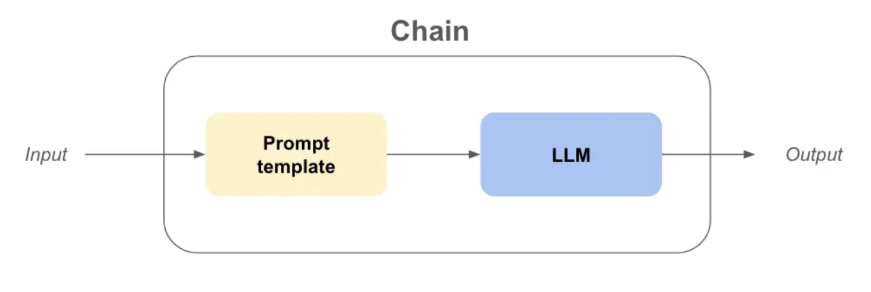

In [ ]:
# Set up the LLM and prompt
llm = OpenAI(temperature=0.2,
          openai_api_key=OPENAI_API_KEY
       )

prompt = PromptTemplate(
    input_variables=["product"],
    template="What is a good name for a company that makes {product}?",
)

In [ ]:
# Bind the prompt with the llm using LangChain Expression Language
chain = prompt | llm

# Execute the chain
print(chain.invoke("gaming laptop"))



"EliteTech Gaming" or "ApexGaming Laptops"


2.   **Sequential Chain** - *Connects multiple chains by using each chain's output as the input for the next, running them in sequence to create a smooth flow of processes.*

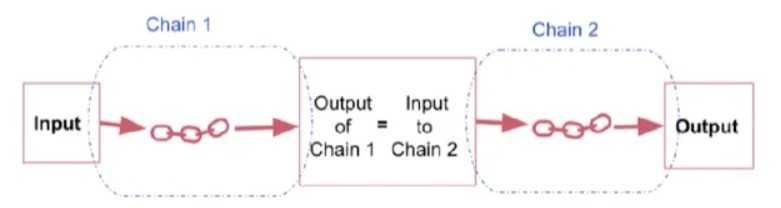

In [ ]:
first_prompt = ChatPromptTemplate.from_template(
    "What is the best name to describe a company that makes {product}?"
)
chain_one = LLMChain(llm=llm, prompt=first_prompt)

In [ ]:
# This is an LLMChain to write second chain
llm = OpenAI(temperature=0.7, openai_api_key=OPENAI_API_KEY)

second_prompt = ChatPromptTemplate.from_template(
    "Write a 20 words description for the following company:{company_name}"
)

chain_two = LLMChain(llm=llm, prompt=second_prompt)

In [ ]:
#Bind both chains together into a SimpleSequentialChain
overall_simple_chain = SimpleSequentialChain(chains=[chain_one, chain_two],
                                             verbose=True
                                            )
overall_simple_chain.run("gaming laptop")



> Entering new SimpleSequentialChain chain...


"EliteTech Gaming Laptops"


"Experience unparalleled gaming performance with EliteTech's cutting-edge laptops designed for the ultimate gaming experience."

> Finished chain.


'\n\n"Experience unparalleled gaming performance with EliteTech\'s cutting-edge laptops designed for the ultimate gaming experience."'

3.   **Router Chain** - *Directs inputs to the appropriate specialized subchain based on the input type, using a default chain if it cannot make a decision.*

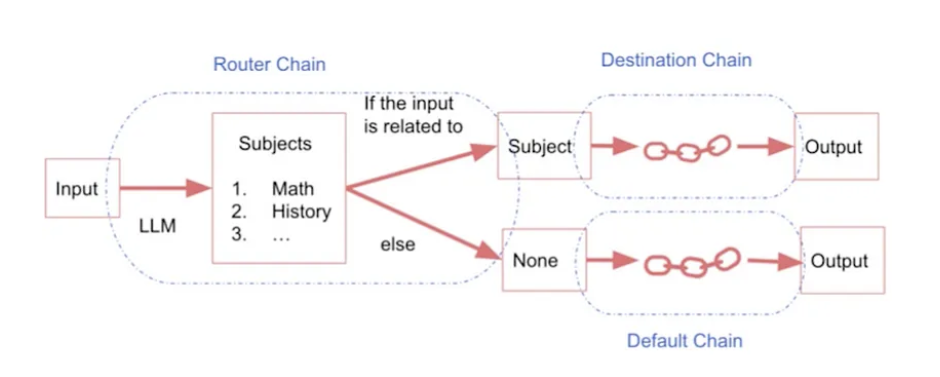

In [ ]:
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise\
and easy to understand manner. \
When you don't know the answer to a question you admit\
that you don't know.

Here is a question:
{input}"""


math_template = """You are a very good mathematician. \
You are great at answering math questions. \
You are so good because you are able to break down \
hard problems into their component parts,
answer the component parts, and then put them together\
to answer the broader question.

Here is a question:
{input}"""


history_template = """You are a very good historian. \
You have an excellent knowledge of and understanding of people,\
events and contexts from a range of historical periods. \
You have the ability to think, reflect, debate, discuss and \
evaluate the past. You have a respect for historical evidence\
and the ability to make use of it to support your explanations \
and judgements.

Here is a question:
{input}"""

In [ ]:
# Defining the prompt templates
prompt_infos = [
    {
        "name": "physics",
        "description": "Good for answering questions about physics",
        "prompt_template": physics_template
    },
    {
        "name": "math",
        "description": "Good for answering math questions",
        "prompt_template": math_template
    },
    {
        "name": "History",
        "description": "Good for answering history questions",
        "prompt_template": history_template
    }
]

In [ ]:
#Create a destination chain dictionary for each of the three prompt templates
destination_chains = {}
for p_info in prompt_infos:
    name = p_info["name"]
    prompt_template = p_info["prompt_template"]
    prompt = ChatPromptTemplate.from_template(template=prompt_template)
    chain = LLMChain(llm=llm, prompt=prompt)
    destination_chains[name] = chain

#Create a key:value mapping for each prompt template as input to the multi-prompt router template
destinations = [f"{p['name']}: {p['description']}" for p in prompt_infos]
destinations_str = "\n".join(destinations)

In [ ]:
#Design a multi prompt router template to choose the appropriate template based on the input user question
MULTI_PROMPT_ROUTER_TEMPLATE = """Given a raw text input to a \
language model select the model prompt best suited for the input. \
You will be given the names of the available prompts and a \
description of what the prompt is best suited for. \
You may also revise the original input if you think that revising\
it will ultimately lead to a better response from the language model.

<< FORMATTING >>
Return a markdown code snippet with a JSON object formatted to look like:
```json
{{{{
    "destination": string \ name of the prompt to use or "DEFAULT"
    "next_inputs": string \ a potentially modified version of the original input
}}}}
```

REMEMBER: "destination" MUST be one of the candidate prompt \
names specified below OR it can be "DEFAULT" if the input is not\
well suited for any of the candidate prompts.
REMEMBER: "next_inputs" can just be the original input \
if you don't think any modifications are needed.

<< CANDIDATE PROMPTS >>
{destinations}

<< INPUT >>
{{input}}

<< OUTPUT (remember to include the ```json)>>"""

In [ ]:
router_template = MULTI_PROMPT_ROUTER_TEMPLATE.format(
    destinations=destinations_str
)
router_prompt = PromptTemplate(
    template=router_template,
    input_variables=["input"],
    output_parser=RouterOutputParser(), # Parser for output of router chain in the multi-prompt chain.
)

router_chain = LLMRouterChain.from_llm(llm, router_prompt)

In [ ]:
#Create a LLMChain for a default user input
default_prompt = ChatPromptTemplate.from_template("{input}")
default_chain = LLMChain(llm=llm, prompt=default_prompt)

In [ ]:
chain = MultiPromptChain(router_chain=router_chain,
                         destination_chains=destination_chains,
                         default_chain=default_chain, verbose=True
                        )

In [ ]:
chain.run("What is 2 + 2?")



> Entering new MultiPromptChain chain...
math: {'input': 'What is 2 + 2?'}
> Finished chain.


'\n\nRobot: Thank you for the compliment! The answer to your question is 4.'

In [ ]:
chain.run("What is black body radiation?")



> Entering new MultiPromptChain chain...
physics: {'input': 'What is black body radiation?'}
> Finished chain.


"\n\nBlack body radiation is the electromagnetic radiation emitted by a perfect black body, which is an idealized object that absorbs all of the radiation that falls on it. This radiation is a result of the thermal energy of the object's particles and is emitted at all wavelengths and intensities. The spectrum of black body radiation follows a specific distribution, known as Planck's law, and is influenced by the temperature of the object. This phenomenon has important applications in many fields, such as astronomy and thermodynamics."

In [ ]:
chain.run("What is your name?")



> Entering new MultiPromptChain chain...
None: {'input': 'What is your name?'}
> Finished chain.


'\n\nI am an AI digital assistant and do not have a name. You can call me OpenAI. What can I assist you with?'

### Summary

In this workshop, we have learned about three components of LangChain. Let's review their definition and how to combine them:


*   **Tools:** Tools serve a specific purpose: they can understand user input to produce output such as calculations, code, or text. In this training, we shared examples of pre-built tools such as a Wikipedia Querying tool and a Python REPL tool. We also showed examples of building custom tools to address more complex needs.
*   **Agents:** Agents leverage language models to determine *which* action to take. An agent can choose which chains or tools to use. In this workshop, we explored an example of agent given 3 tools: Division, Subtraction, and Exponentiation. When given a complex calculation, the agent is able to show step-by-step output to reach the final result. We also showed an example of building agents that use pre-built tools to execute a specific task.
*  **Chains:** Chains are a *predetermined* sequence of LLMs. In this workshop we presented a simple example to answer the question "What company makes the best [product]. We also presented how Chains can increase in complexity through Routed Chains, where inputs are directed to different destination chains to best answer the question.




### Resources

You can find more information and examples on these LangChain concepts below:

1.   https://python.langchain.com/v0.2/docs/introduction/   
2.   https://python.langchain.com/v0.1/docs/modules/tools/
3.   https://python.langchain.com/v0.1/docs/modules/agents/
4.   https://python.langchain.com/v0.1/docs/modules/chains/
5.   https://github.com/pinecone-io/examples/blob/master/learn/generation/langchain/handbook/06-langchain-agents.ipynb
6.   https://github.com/pinecone-io/examples/blob/master/learn/generation/langchain/handbook/02-langchain-chains.ipynb   
7.   https://python.langchain.com/v0.2/docs/integrations/tools/wikipedia/
8.   https://www.analyticsvidhya.com/blog/2023/10/a-comprehensive-guide-to-using-chains-in-langchain/